### 📊 Matplotlib Cheatsheet for AI/ML Workflows

- Matplotlib is Python's core plotting library and is the foundation of most Python plots and libraries (including Pandas and Seaborn) 
    - It gives you fine control over visuals and is essential for custom training plots, confusion matrices, and feature visualizations in AI/ML.
- Two main ways to use Matplotlib: 
    - Pyplot / Functional Interface (plt.plot())
        - This is quick and convenient, and used for quick-and-dirty, smaller scale visualisations
        - Can think of it as using a state machine that remembers its current state, and changes state based on my inputs (e.g. vending machine default is the "waiting for money" state, insert $1 and now in the "waiting for selection" state, and press B3, dispenses drink and returns to the "waiting for money" state)
            - I.e. call plt.plot(), plt.title(), plt.xlabel() directly without explicitly assigning an object, and Matplotlib keeps track of the current figure and current axes internally. 
            - But the downside is that its harder to debug, we lose fine-grained control and cannot easily work with multiple figures or axes in parallel 
    - Object-Oriented Interface (fig, ax = plt.subplots())
        - Create the figure and axes objects and then call methods on them
            - Imagine I want to draw multiple charts on a poster. The poster itself is Figure, and each individual chart box is an Axes
                - fig (Figure) manages the entire canvas and is responsible for overall figure-level settings (e.g. figsize, fig.suptitle(), layout with tight_layout). We also use fig.savefig("save_title.png", dpi=300, bbox_inches='tight') when we are saving the entire figure 
                - ax (Axes) controls the actual plotting (lines, scatter, titles, axis labels, gridlines), and each ax is a complete, self-contained plotting space (with its own set_title, set_xlabel, plot etc)
                -plt.subplots(nrows, ncols) returns 
                    - ax: single Axes if nrows * ncols == 1
                    - 1D array if nrows ==1 or ncols ==1
                    - 2D array if both ?1 
                - Good habit is to always flatten the axes grid for easy iteration 
                    - fig, axes = plt.subplots(2,2)
                    - for ax in axes.flat: 
                        ax,plot()
            - E.g. fig, axes = plt.subplots(2,2)
                - fig is still one canvas 
                - axes is a 2*2 array of Axes objects
            - I can then do axes[0,0].plot(x,y) or axes[1,1].plot(a,b)
        - This enables fine-tuned control, subplots, multiple axes, styling etc
- In AI/ML, plotting libraries are especially useful for 
    - Visualising loss/accuracy curves 
    - Showing confusion matrices 
    - Plotting feature importances 
    - Creating clean model eval charts 

This notebook walks through the two main ways to use Matplotlib as outlined above


## 🔍 OO-style vs Functional-style in Matplotlib

| **Action**                             | **OO-style (`ax` methods)**                       | **Functional-style (`plt` functions)**          | **Notes** |
|----------------------------------------|--------------------------------------------------|------------------------------------------------|-----------|
| Set x-axis limits                      | `ax.set_xlim(left, right)`                       | `plt.xlim(left, right)`                        | Controls min/max of x-axis |
| Set y-axis limits                      | `ax.set_ylim(bottom, top)`                       | `plt.ylim(bottom, top)`                        | Controls min/max of y-axis |
| Set x-axis label                       | `ax.set_xlabel("Epoch")`                         | `plt.xlabel("Epoch")`                          | Label under x-axis |
| Set y-axis label                       | `ax.set_ylabel("Loss")`                          | `plt.ylabel("Loss")`                           | Label beside y-axis |
| Set plot title                         | `ax.set_title("Training Curve")`                 | `plt.title("Training Curve")`                  | Title above the plot |
| Set tick values                        | `ax.set_xticks([...])` / `ax.set_yticks([...])`  | `plt.xticks([...])` / `plt.yticks([...])`      | Specify tick locations |
| Set tick label font size, direction    | `ax.tick_params(labelsize=12, direction='in')`   | `plt.tick_params(labelsize=12, direction='in')`| Control tick appearance |
| Add gridlines                          | `ax.grid(True)`                                  | `plt.grid(True)`                               | Show background grid |
| Show legend                            | `ax.legend()`                                    | `plt.legend()`                                 | Uses labels from `label=...` |
| Save figure                            | `fig.savefig("plot.png", dpi=300)`               | `plt.savefig("plot.png", dpi=300)`             | Works in both, but clearer with OO-style |
| Add text annotation                    | `ax.text(x, y, "Note")`                          | `plt.text(x, y, "Note")`                       | Adds custom text to plot |



In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

#Simulated training data 
epochs = np.arange(1,11) #generate a range of integers from 1 to 10 (ends inclusive)
train_loss = np.sort(np.random.uniform(0.3, 0.8, size=10))[::-1] #draws 10 samples from a uniform distribution between low=0,3 and high=0.8 and sorts them in descenting order. Note that np.sort() will sort in ascending order, and [::-1] reverses the order
val_loss = np.sort(np.random.uniform(0.4, 0.9, size=10))[::-1] #draws 10 samples from a uniform distribution between low=0.4 and high=0.9. Note that np.sort() will return a sorted array in ascending order, and [::-1] reverses the order 
#Note: in Python slicing syntax, we have [start:stop:step] with start inclusive and stop exclusive. Step means how many indices to skip: positive = forward and negative = backward
#Hence [::-1] means take the whole array, but start from the end and move backwards with step -1
#the :: just separates the three arguments start, stop, step, and if dont' specify, start defaults to beginning (0), stop defaults to end (len), and step defaults to +1

<function matplotlib.pyplot.show(close=None, block=None)>

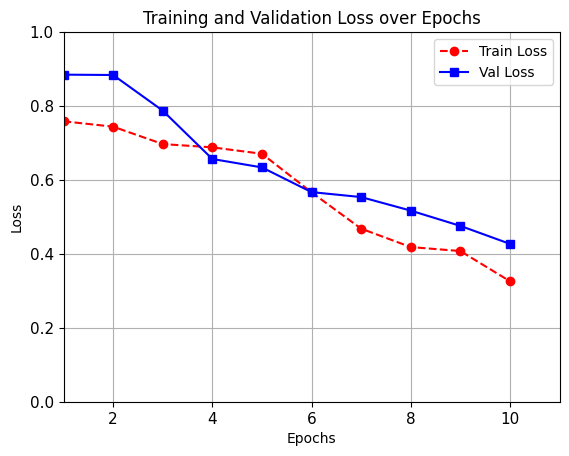

In [14]:
#Functional Style Example 
plt.plot(epochs, train_loss, label="Train Loss", color='red', linestyle='--', marker='o') #dot markers. Label will be used for the legend later
plt.plot(epochs, val_loss, label='Val Loss', color='blue', marker='s') #square markers. for color, can either specify natural language or hex code. linestyle can be "--", "-" etc
#In this case, because the current state is the current fig and ax, when i call plots in succession it continues to plot on the same axis 
#Same as when I set the titles and stuff below

#Set the overall title, x and y labels 
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")

#Set the y and x limits 
plt.ylim(0,1) 
plt.xlim(1,11)

#Set the ticks and fonts 
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tick_params(axis='x', rotation=360)

#Show legend and grid 
plt.legend()
plt.grid(True)
plt.show


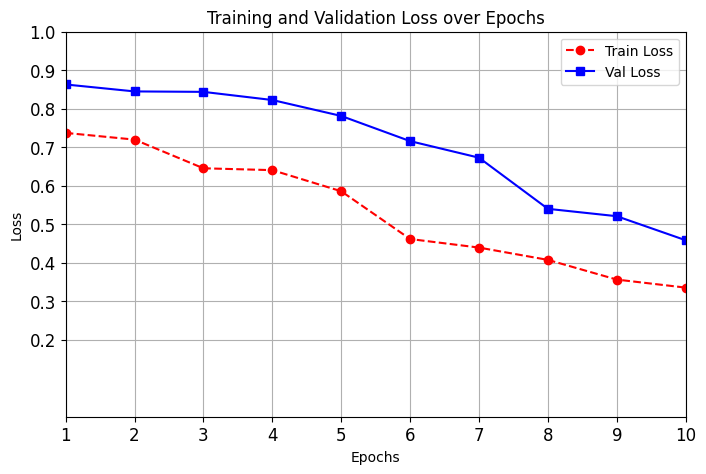

In [17]:
#Equivalent OOP plot 
import matplotlib.pyplot as plt 
import numpy as np 

#Simulated loss values 
epochs = np.arange(1,11)
train_loss = np.sort(np.random.uniform(0.3,0.8,10))[::-1]
val_loss = np.sort(np.random.uniform(0.4, 0.9, 10))[::-1]

#In this case there's only one plot, so only one ax object
fig, ax = plt.subplots(figsize=(8,5)) #create figure and axes
ax.plot(epochs, train_loss, label='Train Loss', marker='o', color='red', linestyle='--')
ax.plot(epochs, val_loss, label="Val Loss", color='blue', marker='s', linestyle='-' )

ax.set_title("Training and Validation Loss over Epochs")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.tick_params(axis='both', labelsize=12) #controls font size of the tick numbers

#Set x, y lim to control the visibile window 
ax.set_xlim(1,10)
ax.set_ylim(0, 1.0)

# Tick control to customise spacing and frequency of ticks
ax.set_xticks(np.arange(1, 11, 1))       # ticks at every epoch
ax.set_yticks(np.round(np.linspace(0.2, 1.0, 9), 2))  # evenly spaced ticks on y-axis

ax.legend()
ax.grid(True)

plt.show()

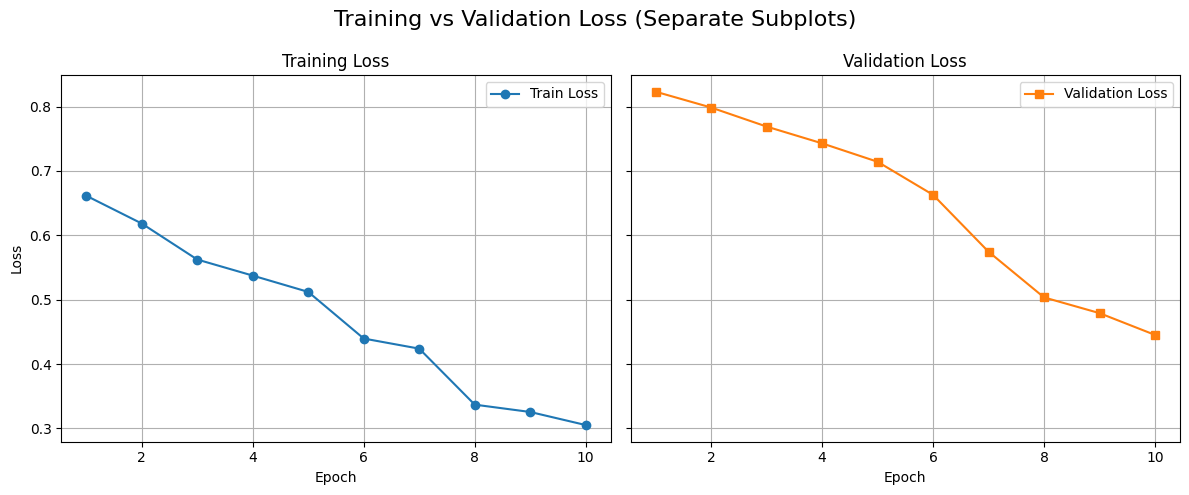

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate data
epochs = np.arange(1, 11)
train_loss = np.sort(np.random.uniform(0.3, 0.8, 10))[::-1]
val_loss = np.sort(np.random.uniform(0.4, 0.9, 10))[::-1]

# Create 1 row × 2 columns of subplots
# axes is a 1x2 NumPy array of Axes objects: [ax0, ax1]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Plot on the first subplot (left)
axes[0].plot(epochs, train_loss, label="Train Loss", marker='o', color='tab:blue')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Plot on the second subplot (right)
axes[1].plot(epochs, val_loss, label="Validation Loss", marker='s', color='tab:orange')
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].grid(True)
axes[1].legend()

# Add a title to the entire figure (not just one subplot)
fig.suptitle("Training vs Validation Loss (Separate Subplots)", fontsize=16)

# Automatically adjust spacing between subplots to prevent overlap
plt.tight_layout()

# Reserve space for the suptitle by adjusting top margin
plt.subplots_adjust(top=0.85)

# Display the final plot
plt.show()
